<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Introduction to Logistic Regression 

---

### About
An introduction to Logistic Regression: what it is, how it works, and how to run a model using `scikit-learn`.

### Learning Objectives
- Fit, evaluate, and generate predictions from a Logistic Regression model in `scikit-learn`.

### Learning Objectives
- Describe the principles of Logistic Regression.
- Describe how logistic regression is similar to and different from linear regression.
- Interpret the coefficients of a Logistic Regression model.
- State the assumptions of a Logistic Regression model.
- Fit, evaluate, and generate predictions from a Logistic Regression model in `scikit-learn`.

### Notebook Guide
- Imports
- Data Set: Graduate School Admissions
- Predicting Admission to College
- Fitting and making predictions with a logistic regression model in `scikit-learn`
- Now You Try: Multivariate Logistic Regression
- Interpreting the coefficients in a logistic regression model
- What about Multiclass Classification?
- Conclusion and Bonuses

# Imports

In [25]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import seaborn as sns

# Import train_test_split
from sklearn.model_selection import train_test_split

# Import DummyClassifier to calculate the baseline (null) model
from sklearn.dummy import DummyClassifier

# Import logistic regression
from sklearn.linear_model import LogisticRegression

# Data Set: Graduate School Admissions

---

In this session, we'll be applying logistic regression to solve the following problem: **"Given their GPA, will a student be admitted to a specific graduate program?"**

In [26]:
# Read in the data
admissions = pd.read_csv('../data/grad_admissions.csv', sep = ',' )

In [27]:
# Check first five rows
admissions.head()

,admit,gre,gpa
0,0,380.0,2.915018
1,1,660.0,4.044540
2,1,800.0,4.950714
3,1,640.0,3.921994
4,0,520.0,2.069878


In [28]:
# Look at the overall properties of the data
admissions.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   4000 non-null   int64  
 1   gre     3980 non-null   float64
 2   gpa     3980 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 93.9 KB


The columns are:
- `admit`: A binary 0/1 variable indicating whether or not a student was admitted, where 1 means admitted and 0 means not admitted.
- `gre`: The student's [GRE (Graduate Record Exam)](https://en.wikipedia.org/wiki/Graduate_Record_Examinations) score.
- `gpa`: The student's [GPA](https://en.wikipedia.org/wiki/Grading_in_education).

In [29]:
# How many missing values do we have in each column?
admissions.isnull().mean().sort_values()*100

admit    0.0
gre      0.5
gpa      0.5
dtype: float64

In [30]:
# Drop every row that has an NA
admissions.dropna(inplace=True)

<details><summary>What assumption are we making when we drop rows that have at least one NA in it?</summary>
    
- We assume that what we drop looks like what we have observed. That is, there's nothing special about the rows we happened to drop.
- We might say that what we dropped is a random sample of our whole data.
- It's not important to know this now, but the formal term is that our data is **missing completely at random**.
</details>

In [31]:
# What is the distribution of your target?
admissions["admit"].value_counts(normalize=True)*100

admit
0    68.261965
1    31.738035
Name: proportion, dtype: float64

# Predicting Admission to College
---

<a id='plot-reg'></a>
### What if we predicted `admit` with `gpa` using Linear Regression?

Looking at the plot below, what are problems with using a regression?

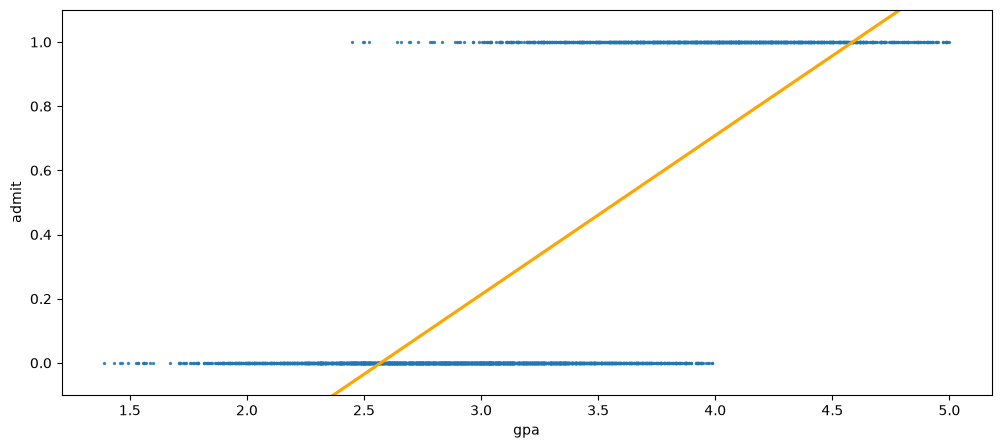

In [32]:
plt.figure(figsize = (12, 5))
sns.regplot(x=admissions['gpa'], y=admissions['admit'], data=admissions,
            ci = False, scatter_kws = {'s': 2},
            line_kws = {'color': 'orange'})
plt.ylim(-0.1, 1.1);

<details><summary>The big problem...</summary>
    
...is that Linear Regression we predict a continuous variable, but here we want to predict a class: one of two options.

</details>

## Predicting a Binary Class

In our case we have two classes: `1=admitted` and `0=rejected`.

The logistic regression is still solving for $\hat{y}$. However, in our binary classification case, $\hat{y}$ will be the probability of $y$ being one of the classes.

$$
\hat{y} = P(y = 1)
$$

We'll still try to fit a "line" of best fit to this... except it won't be perfectly linear. We need to *guarantee* that the right-hand side of the regression equation will evaluate to a probability. (That is, some number between 0 and 1!)

# Fitting and making predictions with a logistic regression model in `scikit-learn`
---

We can follow the same steps to build a logistic regression model that we follow to build a linear regression model.

1. Define X & y
2. Instantiate the model
3. Fit the model
4. Generate predictions
5. Evaluate model

In [33]:
# Step 1: Define X & y, and split into training & testing sets
X = admissions[['gpa']]
y = admissions['admit']

X_train, X_test, y_train, y_test = train_test_split(
                                        X, 
                                        y,
                                        random_state = 50, 
                                        stratify=y)

In [34]:
# Step 2: Instantiate our model
logreg = LogisticRegression()

# Step 3: Fit our model
logreg.fit(X= X_train,
           y=y_train)
           
print(f'Logistic Regression Intercept: {logreg.intercept_}')
print(f'Logistic Regression Coefficient: {logreg.coef_}')

Logistic Regression Intercept: [-17.94227441]
Logistic Regression Coefficient: [[5.02841061]]


There are two methods in `sklearn` to be aware of when using logistic regression:
- `.predict()`
- `.predict_proba()`

In [35]:
# Step 4 (part 1): Generate predicted values
logreg.predict(X_train)


array([0, 0, 0, ..., 1, 0, 0], shape=(2977,))

In [36]:
# Step 4 (part 2): Generate predicted probabilities
logreg.predict_proba(X_train)

array([[9.98677570e-01, 1.32243021e-03],
       [9.94941083e-01, 5.05891713e-03],
       [9.99610099e-01, 3.89901007e-04],
       ...,
       [4.41068371e-03, 9.95589316e-01],
       [5.11545721e-01, 4.88454279e-01],
       [9.99748656e-01, 2.51344231e-04]], shape=(2977, 2))

<details><summary>How would you interpret the predict_proba() output?</summary>
    
- This shows the probability of being rejected ($P(y=0)$) and the probability of being admitted ($P(y=1)$) for each observation in the testing data set.
- The first array, corresponds to the first testing observation.
    - The `.predict()` value for this observation is 0. This is because $P(y=0) > P(y=1)$.
- The second array, corresponds to the second testing observation.
    - The `.predict()` value for this observation is 0. This is because $P(y=0) > P(y=1)$.
</details>

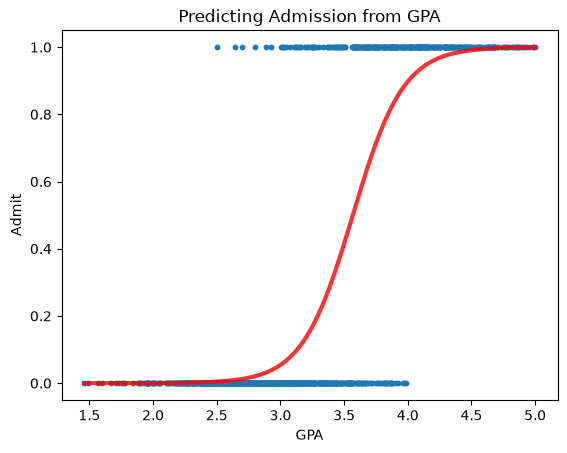

In [37]:
# Visualizing logistic regression probabilities

plt.figure()
plt.scatter(X_test, y_test, s = 10);

plt.plot(X_test.sort_values('gpa'), 
         logreg.predict_proba(X_test.sort_values('gpa'))[:,1], # extracting the probability of the positive class
         color = 'red', alpha = 0.8, lw = 3)

plt.xlabel('GPA')
plt.ylabel('Admit')
plt.title('Predicting Admission from GPA');

In [39]:
# Step 5: Evaluate model

# Training Score
logreg.score(X_train,y_train)

0.8941887806516627

In [41]:
# Testing Score
logreg.score(X_test,y_test)

0.9063444108761329

By default, the `.score()` method for classification models gives us the accuracy score.

$$
\begin{eqnarray*}
\text{Accuracy} = \frac{\text{number of correct predictions}}{\text{number of total predictions}}
\end{eqnarray*}
$$

<details><summary>Remind me: what does .score() tell me for a regression model?</summary>
    
- The $R^2$ score.
- Remember that $R^2$ is the proportion of variance in our $Y$ values that are explained by our model.
</details>

In [43]:
admissions['admit'].value_counts(normalize=True)

admit
0    0.68262
1    0.31738
Name: proportion, dtype: float64

In [44]:
# Compare with a baseline (null) model

dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)

# Evaluate on the test
dummy_clf.score(X_test, y_test)

0.6827794561933535

## Predict on unseen data

How likely would a student with GPA = 3.5 be admitted by the university?

In [46]:
# here we care about the probability not the final binary outcome
probabilities = logreg.predict_proba([[3.5]])
probabilities

c:\Users\TALAL ALOTHMAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.58487957, 0.41512043]])

In [48]:
print(f"Probability of rejection: {probabilities[0,0]:.1%}")
print(f"Probability of admission: {probabilities[0,1]:.1%}")

Probability of rejection: 58.5%
Probability of admission: 41.5%


# Now You Try: Multivariate Logistic Regression

---

Create a logistic regression model that uses GRE and both GPA and GRE.  How does it compare with the simple model we created?

In [ ]:
# Step 1: Define X & y, and split into training & testing sets
X = 
y = 



In [ ]:
# Step 2: Instantiate our model
logreg2 = 

# Step 3: Fit our model


LogisticRegression()

In [ ]:
# Step 4 (part 1): Generate predicted values


array([0, 0, 0, 1, 0, 0, 0, 1, 1, 0])

In [ ]:
# Step 4 (part 2): Generate predicted probabilities


array([[0.905, 0.095],
       [0.834, 0.166],
       [0.994, 0.006],
       ...,
       [0.544, 0.456],
       [0.991, 0.009],
       [0.986, 0.014]])

In [ ]:
# Step 5: Evaluate model

# Training score


0.8951965065502183

In [ ]:
# Testing score


0.904330312185297

The model is not better with GRE included.  GRE on its own is a poorer predictor.  The best model here is to just use GPA as the predictor.

---

To the slides!

---

# Interpreting the coefficients in a logistic regression model
---

## Using the log-odds: the natural logarithm of the odds

The combination of converting the "probability of success" to "odds of success," then taking the logarithm of that is called the **logit link function**.

$$
\text{logit}\big(P(y=1)\big) = \ln\bigg(\frac{P(y=1)}{1-P(y=1)}\bigg) = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p
$$

We've bent our line how we want... but how do we interpret our coefficients?

Given this model, **a one-unit change in $x_i$ implies a $\beta_i$ unit change in the log odds of success**.

**This is annoying**.  We often convert log-odds back to "regular odds" when interpreting our coefficient (and then on to probability)... our mind understands odds better than the log of odds.

We can get rid of the natural log on the left-hand side by "exponentiating" each side.
$$
\begin{eqnarray*}
\Rightarrow \frac{P(y=1)}{1-P(y=1)} &=& e^{\Bigg(\beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p\Bigg)} \\
\end{eqnarray*}
$$

### Interpretation:
**A one-unit change in $x_i$ means that success is $e^{\beta_i}$ times as likely.**

In [ ]:
logreg.________

array([[5.02841061]])

<details><summary> I want to interpret the coefficient $\hat{\beta}_1$ for my logistic regression model. How would I interpret this coefficient?</summary>
    
- Our model is that $\log\bigg(\frac{P(admit=1)}{1-P(admit=1)}\bigg) = \beta_0 + \beta_1\text{GPA}$.
- As GPA increases by 1, the log-odds of someone being admitted increases by 5.02.
- As GPA increases by 1, the odds of someone being admitted are about $e^{5.02}$ times as high.
- As GPA increases by 1, the odds of someone being admitted are about 153 times as high
</details>

> Hint: Use the [np.exp](https://docs.scipy.org/doc/numpy/reference/generated/numpy.exp.html) function.

In [ ]:
# Use np.exp() to exponentiate the coefficient.
odd_ratio = ________
odd_ratio

152.69013522372913

---

To the slides!

---

# What about Multiclass Classification?
---

Logistic regression is **only** for binary classification problems! However, there are two "hacks" that allow us to fit multiclass classification problems using the same/similar methodology. They are:

## Multinomial logistic regression
Normally, logistic regression is based off of the _Bernoulli distribution_, since our y-variable can be represented with a Bernoulli trial. We can instead base our y-variable off the _multinomial distribution_ and fit a model that way. It's more theoretically "pure" than OVR below, but less commonly used.

**How?**
```python
LogisticRegression(solver='...')
```
All solvers except `liblinear` will handle multiclass (the default is `lbfgs`).

### The math behind the scenes

For binary logistic regression, for each observation you calculate one linear score:

$$
z=\beta_0+\beta_1X_1+\cdots
$$

That score can be anywhere from $(-\infty)$ to $(+\infty)$. Then we convert this score into:

$$
P(\text{success})\in[0,1]
$$

and automatically:

$$
P(\text{failure})=1-P(\text{success})
$$

So each observation gets something like:

```text
Success = 0.80
Failure = 0.20
```

### Now suppose we have Cat, Dog and Bird

Using **Bird as the reference**, the model calculates **two scores** for every observation:

$$
z_{Cat}=\log\left(\frac{P(Cat)}{P(Bird)}\right)
$$

$$
z_{Dog}=\log\left(\frac{P(Dog)}{P(Bird)}\right)
$$

Each of those scores can also range from:

$$
-\infty \rightarrow +\infty
$$

Suppose for one observation the model produces:

```text
Cat vs Bird log-odds = 1
Dog vs Bird log-odds = 0.5
```

Exponentiating gives the relative odds:

```text
Cat vs Bird = e¹   = 2.72
Dog vs Bird = e⁰·⁵ = 1.65
Bird         =       1    ← reference
```

Now we have relative strengths:

```text
Cat  = 2.72
Dog  = 1.65
Bird = 1
```

Which can be explained as

```text
For this observation, the model considers Cat about 2.7 times more likely than Bird.
```

Normalize them so they sum to 1:

$$
2.72+1.65+1=5.37
$$

Therefore:

```text
P(Cat)  = 2.72 / 5.37 = 0.51
P(Dog)  = 1.65 / 5.37 = 0.31
P(Bird) = 1    / 5.37 = 0.19
```

So this observation receives:

```text
Cat  → 51%
Dog  → 31%
Bird → 19%
```

and the prediction is **Cat**.


> **Binary logistic regression:** one score is converted into probabilities for two classes using sigmoid.

> **Multinomial logistic regression:** several class scores are converted into probabilities for all classes , and those probabilities sum to 1.

## One-vs-Rest (OVR) logistic regression
A more common alternative is the _one-versus-rest_ technique. It works like this:

1. For category $k$, set $y = 1$ when the response is $k$ and $y = 0$ otherwise
1. Fit a logistic regression with this new $y$, and record the $\hat y$ for each observation
1. Repeat steps 1 and 2 for each category in our response variable
1. The true prediction is the $\hat y$ with the highest probability after all models are fit


**How?**

```python
sklearn.multiclass.OneVsRestClassifier()
```
You cannot do OVR in `LogisticRegression` in `scikit-learn`, but the library offers a `OneVsRestClassifier` classifier specifically for it: [`scikit-learn` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html#sklearn.multiclass.OneVsRestClassifier)

#### (BONUS - outside of class) Try multinomial regression with the iris data set.

In [ ]:
iris = pd.read_csv('../data/iris.csv')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


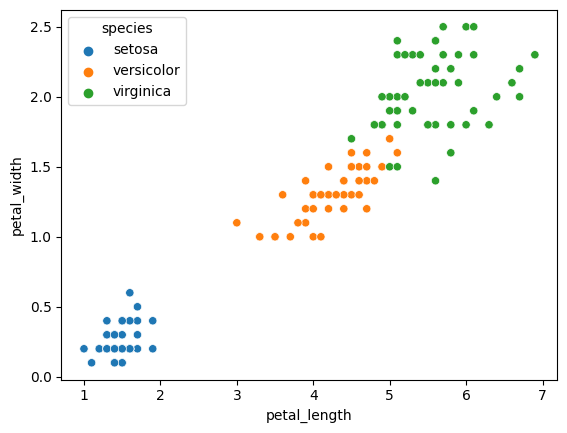

In [ ]:
# create a scatter matrix of petal_length and petal_width and plot each species in a different color
??

In [ ]:
# Step 1: Define X & y, and split into training & testing sets
X = 
y = 

X_train, X_test, y_train, y_test = 

In [ ]:
# Step 2: Instantiate our model


# Step 3: Fit our model


Logistic Regression Intercept: [  9.00953843   1.86864855 -10.87818698]
Logistic Regression Coefficient: [[-0.39352486  0.96242398 -2.37516107 -0.9987522 ]
 [ 0.50847792 -0.25477254 -0.21300601 -0.77574639]
 [-0.11495306 -0.70765144  2.58816708  1.77449859]]


In [ ]:
# Step 4: Evaluate model


0.975

In [ ]:
# Step 5: Compare with a baseline (null) model



0.3

# Conclusion and Bonuses
---

The goal of logistic regression is to find the best-fitting model to describe the relationship between a binary outcome and a set of independent variables.

Logistic regression generates the coefficients of a formula to predict a logit transformation of the probability that the characteristic of interest is present.

## Interview Questions

<details><summary>What is the difference between a classification and a regression problem?</summary>
    
- A classification problem has a categorical $Y$ variable. A regression problem has a numeric $Y$ variable.
</details>

<details><summary>What are some of the benefits of logistic regression as a classifier?</summary>

(Answers may vary; this is not an exhaustive list!)
- Logistic regression is a classification algorithm that shares similar properties to linear regression.
- The coefficients in a logistic regression model are interpretable. (They represent the change in log-odds caused by the input variables.)
- Logistic regression is a very fast model to fit and generate predictions from.
- It is by far the most common classification algorithm.

**Note**: The original interview question was "If you're comparing decision trees and logistic regression, what are the pros and cons of each?"
</details>

## (BONUS) Solving for the Beta Coefficients

Logistic regression minimizes the "deviance," which is similar to the residual sum of squares in linear regression, but is a more general form. 

**There's no closed-form solution to the beta coefficients like in linear regression, and the betas are found through optimization procedures.**
- We can't just do $\hat{\beta} = (X^TX)^{-1}X^Ty$ like we can in linear regression!

The `solver` hyperparameter in sklearn's `LogisticRegression` class specifies which method should be used to solve for the optimal beta coefficients (the coefficients that minimize our cost function). [This](https://www.linkedin.com/posts/justmarkham_sklearntips-machinelearning-python-activity-6654000730321534976-Um6C/) is a good post by Kevin Markham that compares the solvers.

If you're particularly interested in the math, here are two helpful resources:
- [A good blog post](http://www.win-vector.com/blog/2011/09/the-simpler-derivation-of-logistic-regression/) on the logistic regression beta coefficient derivation.
- [This paper](https://www.stat.cmu.edu/~cshalizi/402/lectures/14-logistic-regression/lecture-14.pdf) is also a good reference.

## (BONUS) The Logistic Function

The inverse function of the logit is called the **logistic function**. 

By inverting the logit, we can have the right side of our regression equation solve explicitly for $P(y = 1)$:

$$
P(y=1) = logit^{-1}\left(\beta_0 + \sum_{j}^p\beta_jx_j\right)
$$

Where:

$$
logit^{-1}(a) = logistic(a) = \frac{e^{a}}{e^{a} + 1}
$$ 

Giving us:

$$
P(y=1) = \frac{e^{\left(\beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p\right)}}{e^{\left(\beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p\right)}+1}
$$